# Kernel merging — would the decoder have decided differently?

Replays one saved run offline with **weight-only kernel merging** (Hu et al. 2018, using the
merge rule of Sodkomkham et al. 2016, restricted to the same hex) at several thresholds, and
compares what the decoder decides, bin by bin, against the same replay **without** merging.

**How the replay works** (code in `kernel_merging.py`):

1. Rebuild each trode's encoding model spike by spike, in the order the encoder processed
   them. Checked against the saved `*.encoder.npz` — they must match exactly.
2. Replay every spike through a **merged** copy of that model. An encoding spike joins the
   nearest bump *in its own hex* if that bump's center is within **TAU × σ** (σ = the mark
   kernel std, 20 µV here); otherwise it starts a new bump. A bump's center is the mean of its
   members, its width stays σ, and its **count multiplies its kernel**. TAU = 0 is no merging.
3. Re-decode every 6 ms bin with the real `ClusterlessDecoder`, once with the unmerged votes
   and once per TAU. Both replays use every spike the encoders sent, the same occupancy and
   the same decoder code — **the only difference between them is the merging**.

**"Disagree"** below means the decoded hex (argmax of the posterior) differs between the merged
and the unmerged replay of the same bin.

In [1]:
import os, sys, gc
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

sys.path.insert(0, os.path.abspath('..'))   # the realtime_decoder package
sys.path.insert(0, os.path.abspath('.'))    # kernel_merging.py next to this notebook
import kernel_merging as km

# categorical order is fixed: blue = unmerged / primary series, orange = merged / second series
PAL  = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
        '#e87ba4', '#008300', '#4a3aa7', '#e34948']
C_UNMERGED, C_MERGED = PAL[0], PAL[1]
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURF, BASE = '#e1e0d9', '#fcfcfb', '#c3c2b7'
SEQ_BLUE = ['#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
            '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b']
CM_BLUE = mpl.colors.LinearSegmentedColormap.from_list('seq_blue', SEQ_BLUE)
CM_POST = mpl.colors.LinearSegmentedColormap.from_list('seq_post', [SURF] + SEQ_BLUE)

plt.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': BASE, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2.0, 'font.size': 10.5, 'legend.frameon': False,
    'figure.dpi': 110,
})
def style_ax(ax):
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

In [2]:
# ---------------- run selection ----------------
animal     = 'Vinnie'
run_folder = '20260812_r3_80mv_randomwalk'
RUN_DIR    = f'/media/ssd1/decoder_output/{animal}/{run_folder}'
RUN_PREFIX = None            # None -> newest *.rec_merged.h5 in RUN_DIR

# ---------------- replay settings ----------------
TAUS      = [0.5, 1.0, 1.5, 2.0]   # merge thresholds in kernel widths; 0 (no merging) is always included
TAU_VIEW  = 1.0                    # threshold used in section 4 ('where do they disagree')
N_WORKERS = 64                     # parallel processes for the replay
CACHE_DIR = os.path.join(RUN_DIR, 'compression_analysis')   # one .npz per threshold
FORCE     = False                  # True -> ignore the cache and recompute

## 1. Load the run and check the replay is exact

Each trode's model is rebuilt from the per-spike encoder records (`rec_3`) in processing order
(`rec_ind`). If that rebuild doesn't reproduce the saved `*.encoder.npz` exactly, nothing below
can be trusted. (A run started from a preloaded model will not match — the saved model then also
contains the preloaded spikes.)

In [3]:
run = km.Run(RUN_DIR, RUN_PREFIX)
FS = run.cfg['sampling_rate']['spikes']
HEX = np.asarray(run.hex_ids)
print(f'run        : {run.prefix}')
print(f'trodes     : {run.trodes}')
print(f'bins       : {len(run.bins):,} x {run.cfg["decoder"]["time_bin"]["samples"]/FS*1e3:.0f} ms '
      f'= {len(run.bins)*run.cfg["decoder"]["time_bin"]["samples"]/FS/60:.1f} min')
print(f'mark kernel: sigma {run.sigma:g} uV, box +/-{run.box:g} uV, >= {run.n_marks_min} nearby marks to send a spike')

checks = run.check_models()
ok = bool(checks.marks_match.all() and checks.positions_match.all())
print(f'\nreplayed models match the saved encoder.npz for every trode: {ok}')
checks

run        : 20260917_123501_Vinnie_hex_realtime_decoding
trodes     : [2, 5, 8, 12, 15, 18, 22, 25, 28, 31]
bins       : 781,199 x 6 ms = 78.1 min
mark kernel: sigma 20 uV, box +/-20 uV, >= 10 nearby marks to send a spike



replayed models match the saved encoder.npz for every trode: True


,spikes,encoding,saved_model,marks_match,positions_match
trode,,,,,
2,258131,143547,143547,True,True
5,271820,146618,146618,True,True
8,85099,49646,49646,True,True
12,237268,117562,117562,True,True
15,231081,134649,134649,True,True
18,229573,126555,126555,True,True
22,107232,39108,39108,True,True
25,43460,20348,20348,True,True
28,157118,57559,57559,True,True


## 2. Replay with and without merging

The slow part is replaying every spike through the **unmerged** model (it grows to ~150k marks
per trode). With 64 workers this run takes a few minutes; results are cached in `CACHE_DIR`, so
re-running the notebook afterwards is quick.

In [4]:
res = km.replay(run, TAUS, n_workers=N_WORKERS, cache_dir=CACHE_DIR, force=FORCE)
R = res.results

gate_ok = R[0.0]['ref_gate_ok']
print(f"unmerged replay sends exactly the spikes the live encoder sent, for every trode: {all(gate_ok.values())}")
for tau in TAUS:
    print(f"  tau {tau:g}: {R[tau]['n_fallback']:,} spikes sent only by the merged model "
          f"(their vote uses the decoder's logged occupancy)")

tau 0: loaded from cache /media/ssd1/decoder_output/Vinnie/20260812_r3_80mv_randomwalk/compression_analysis/20260917_123501_Vinnie_hex_realtime_decoding.merge_tau0.npz
tau 0.5: loaded from cache /media/ssd1/decoder_output/Vinnie/20260812_r3_80mv_randomwalk/compression_analysis/20260917_123501_Vinnie_hex_realtime_decoding.merge_tau0.5.npz


tau 1: loaded from cache /media/ssd1/decoder_output/Vinnie/20260812_r3_80mv_randomwalk/compression_analysis/20260917_123501_Vinnie_hex_realtime_decoding.merge_tau1.npz


tau 1.5: loaded from cache /media/ssd1/decoder_output/Vinnie/20260812_r3_80mv_randomwalk/compression_analysis/20260917_123501_Vinnie_hex_realtime_decoding.merge_tau1.5.npz
tau 2: loaded from cache /media/ssd1/decoder_output/Vinnie/20260812_r3_80mv_randomwalk/compression_analysis/20260917_123501_Vinnie_hex_realtime_decoding.merge_tau2.npz
unmerged replay sends exactly the spikes the live encoder sent, for every trode: True
  tau 0.5: 332 spikes sent only by the merged model (their vote uses the decoder's logged occupancy)
  tau 1: 2,593 spikes sent only by the merged model (their vote uses the decoder's logged occupancy)
  tau 1.5: 4,625 spikes sent only by the merged model (their vote uses the decoder's logged occupancy)
  tau 2: 5,895 spikes sent only by the merged model (their vote uses the decoder's logged occupancy)


In [5]:
# ---------------- one row per 6 ms bin ----------------
hops = km.hex_hop_distance(run)
post0 = R[0.0]['posterior']
dec0 = post0.argmax(1)
mp_idx = run.bins.mapped_pos.to_numpy()
bins = pd.DataFrame({
    'minutes'      : (run.bins.bin_timestamp_l - run.bins.bin_timestamp_l.iloc[0]).to_numpy() / FS / 60,
    'speed'        : run.bins.velocity.to_numpy(float),
    'actual_idx'   : np.where((mp_idx >= 0) & (mp_idx < run.num_bins), mp_idx, -1),
    'n_spikes'     : R[0.0]['n_used'].astype(int),
    'dec_unmerged' : dec0,
    'pmax_unmerged': post0.max(1),
    'dec_live'     : run.logged_posterior.argmax(1),
})
for tau in TAUS:
    p = R[tau]['posterior']
    d = p.argmax(1)
    bins[f'diff_{tau:g}'] = d != dec0
    bins[f'hops_{tau:g}'] = hops[dec0, d]
    bins[f'tv_{tau:g}'] = 0.5 * np.abs(p - post0).sum(1)
    bins[f'dec_{tau:g}'] = d
gc.collect()
bins.head()

,minutes,speed,actual_idx,n_spikes,dec_unmerged,pmax_unmerged,dec_live,diff_0.5,hops_0.5,tv_0.5,...,tv_1,dec_1,diff_1.5,hops_1.5,tv_1.5,dec_1.5,diff_2,hops_2,tv_2,dec_2
0,0.0000,0.0,0.0,0,3,0.023760,3,False,0.0,0.0,...,0.0,3,False,0.0,0.0,3,False,0.0,0.0,3
1,0.0001,0.0,0.0,0,3,0.023294,3,False,0.0,0.0,...,0.0,3,False,0.0,0.0,3,False,0.0,0.0,3
2,0.0002,0.0,0.0,0,9,0.022985,9,False,0.0,0.0,...,0.0,9,False,0.0,0.0,9,False,0.0,0.0,9
3,0.0003,0.0,0.0,0,9,0.023223,9,False,0.0,0.0,...,0.0,9,False,0.0,0.0,9,False,0.0,0.0,9
4,0.0004,0.0,0.0,0,9,0.023356,9,False,0.0,0.0,...,0.0,9,False,0.0,0.0,9,False,0.0,0.0,9


## 3. How much does each threshold change?

Per threshold:

- **kernels kept** — stored bumps at the end of the session, as a share of training spikes
- **vote change** — how much of a spike's per-hex vote moves to other hexes (0.5 × sum |difference|),
  for spikes sent by both models
- **send flips** — spikes sent by one model but not the other (the ≥10-nearby-marks rule)
- **bins decoded differently** — share of 6 ms bins whose decoded hex changed; also only bins with
  at least one spike, bins where the two hexes are ≥ 2 steps apart, and only bins where the
  unmerged decoder was fairly sure (posterior peak ≥ 0.5)
- **posterior change** — 0.5 × sum |difference| of the whole posterior, per bin

In [6]:
def pct(x):
    return 100 * float(np.mean(x))

rows = []
for tau in [0.0] + TAUS:
    ps = R[tau]['per_spike']
    n_enc = sum(len(ps[t]['n_bumps_after']) for t in run.trodes)
    n_kept = sum(int(ps[t]['n_bumps_after'][-1]) for t in run.trodes if len(ps[t]['n_bumps_after']))
    row = {'tau': tau, 'kernels kept %': 100 * n_kept / n_enc}
    if tau > 0:
        tv = np.concatenate([ps[t]['tv'] for t in run.trodes])
        flips = np.concatenate([ps[t]['sent'] != R[0.0]['per_spike'][t]['sent'] for t in run.trodes])
        k = f'{tau:g}'
        row.update({
            'vote change median %': 100 * np.nanmedian(tv),
            'vote change p95 %': 100 * np.nanpercentile(tv, 95),
            'send flips %': pct(flips),
            'bins decoded differently %': pct(bins[f'diff_{k}']),
            '... bins with spikes %': pct(bins.loc[bins.n_spikes > 0, f'diff_{k}']),
            '... >= 2 hex steps apart %': pct(bins[f'hops_{k}'] >= 2),
            '... where unmerged peak >= 0.5 %': pct(bins.loc[bins.pmax_unmerged >= 0.5, f'diff_{k}']),
            'posterior change median %': 100 * bins[f'tv_{k}'].median(),
            'posterior change p95 %': 100 * bins[f'tv_{k}'].quantile(0.95),
        })
    rows.append(row)
summary = pd.DataFrame(rows).set_index('tau')

live_diff = pct(bins.dec_live != bins.dec_unmerged)
print(f'for scale: the LIVE run decoded a different hex than its own unmerged replay in {live_diff:.1f}% of bins')
print(f'           (it used {run.bins.spike_count.sum():,} spikes; the replay uses all '
      f'{bins.n_spikes.sum():,} that the encoders sent — the rest arrived too late live)')
summary.round(3)

for scale: the LIVE run decoded a different hex than its own unmerged replay in 55.8% of bins
           (it used 746,215 spikes; the replay uses all 1,470,272 that the encoders sent — the rest arrived too late live)


,kernels kept %,vote change median %,vote change p95 %,send flips %,bins decoded differently %,... bins with spikes %,... >= 2 hex steps apart %,... where unmerged peak >= 0.5 %,posterior change median %,posterior change p95 %
tau,,,,,,,,,,
0.0,100.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.5,50.882,0.209,0.334,0.043,3.586,3.412,2.661,0.267,0.852,6.045
1.0,16.787,0.831,1.776,0.361,9.021,8.896,6.448,1.852,2.366,16.172
1.5,7.960,1.681,4.286,0.810,13.109,13.241,8.491,3.356,3.502,24.325
2.0,4.893,3.055,7.846,1.480,20.374,20.684,12.895,6.358,6.134,36.604


### KDE time per spike

Measured separately, in a single process (nothing else running), for the trode with the most
training spikes: spikes from the last 10% of the session against that trode's **final** model —
the worst case. Two evaluation styles, so the two speed-ups can be read separately:

- **today's code** — `get_joint_prob`'s structure (per-channel filter loop, `np.sum(np.square(...))`,
  `np.histogram`), with bump counts as weights when merged
- **faster evaluation** — the same math with `einsum`, `bincount` and the most selective channel
  tested first (votes identical to ~1e-13; see `docs/kernel_compression_plan.md`)

Offline numbers on an idle machine; the live encoder runs slower (other ranks share the machine).
Compare thresholds with each other and with the 6 ms bin, not with live latencies.

In [7]:
big, timing = km.time_kde(run, TAUS)
timing['kernels kept %'] = 100 * timing.kernels / timing.kernels.iloc[0]
print(f'trode {big}, final model, {run.spikes[big].enc.sum():,} training spikes')
timing.round(3)

trode 5, final model, 146,618 training spikes


,kernels,today's code ms,faster evaluation ms,kernels kept %
tau,,,,
0.0,146618,7.593,2.518,100.000
0.5,88192,4.046,1.266,60.151
1.0,29856,1.259,0.429,20.363
1.5,13297,0.756,0.270,9.069
2.0,7418,0.391,0.162,5.059


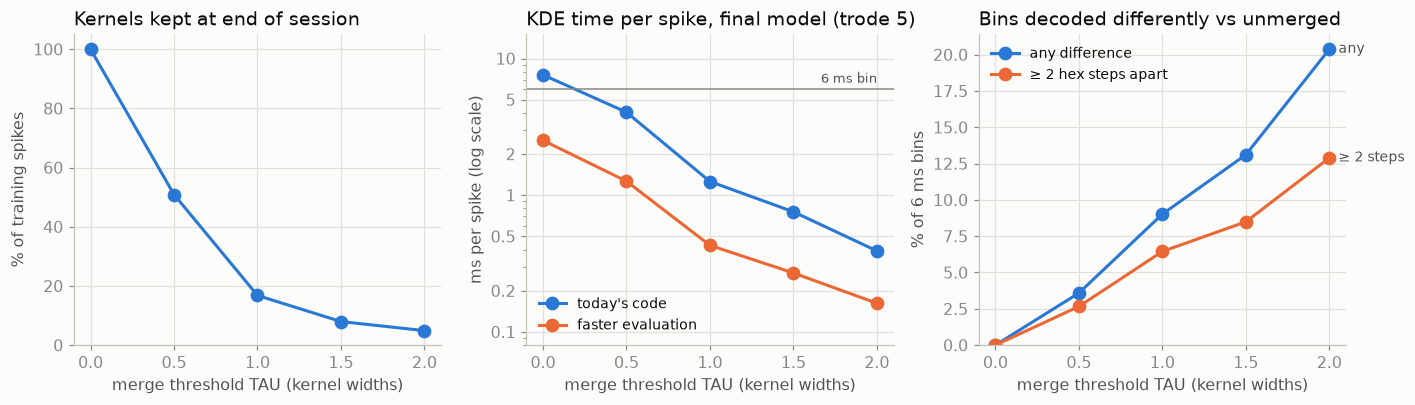

In [8]:
t_all = [0.0] + TAUS
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].plot(t_all, summary['kernels kept %'], color=PAL[0], marker='o', ms=8)
axes[0].set_ylim(0, 105)
axes[0].set_title('Kernels kept at end of session', loc='left')
axes[0].set_ylabel('% of training spikes')

bin_ms = run.cfg['decoder']['time_bin']['samples'] / FS * 1e3
axes[1].plot(t_all, timing["today's code ms"], color=PAL[0], marker='o', ms=8, label="today's code")
axes[1].plot(t_all, timing['faster evaluation ms'], color=PAL[1], marker='o', ms=8, label='faster evaluation')
axes[1].axhline(bin_ms, color=MUTED, lw=1)
axes[1].annotate(f'{bin_ms:.0f} ms bin', (t_all[-1], bin_ms), xytext=(0, 4), textcoords='offset points',
                 ha='right', fontsize=8.5, color=INK2)
axes[1].set_yscale('log')
axes[1].set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
axes[1].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{v:g}'))
axes[1].yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
axes[1].set_ylim(0.08, 15)
axes[1].set_title(f'KDE time per spike, final model (trode {big})', loc='left')
axes[1].set_ylabel('ms per spike (log scale)')
axes[1].legend(loc='lower left', fontsize=9)

d_any = [0.0] + list(summary['bins decoded differently %'].iloc[1:])
d_far = [0.0] + list(summary['... >= 2 hex steps apart %'].iloc[1:])
axes[2].plot(t_all, d_any, color=PAL[0], marker='o', ms=8, label='any difference')
axes[2].plot(t_all, d_far, color=PAL[1], marker='o', ms=8, label='≥ 2 hex steps apart')
for y, lab, c in ((d_any[-1], 'any', INK2), (d_far[-1], '≥ 2 steps', INK2)):
    axes[2].annotate(lab, (t_all[-1], y), xytext=(6, 0), textcoords='offset points',
                     va='center', fontsize=9, color=c)
axes[2].set_ylim(0, None)
axes[2].set_title('Bins decoded differently vs unmerged', loc='left')
axes[2].set_ylabel('% of 6 ms bins')
axes[2].legend(loc='upper left', fontsize=9)

for ax in axes:
    ax.set_xlabel('merge threshold TAU (kernel widths)')
    ax.set_xticks(t_all)
    style_ax(ax)
fig.tight_layout(); plt.show()

## 4. Where do they disagree?  (TAU_VIEW)

Everything in this section is for one threshold, `TAU_VIEW` (set in the settings cell).

In [9]:
k = f'{TAU_VIEW:g}'
assert f'diff_{k}' in bins, f'TAU_VIEW={TAU_VIEW} is not in TAUS'
diff = bins[f'diff_{k}'].to_numpy()
print(f'TAU {k}: {diff.sum():,} of {len(diff):,} bins decoded differently ({100*diff.mean():.2f}%)')

TAU 1: 70,470 of 781,199 bins decoded differently (9.02%)


### 4a. Over the session

Disagreement per 30 s window, next to what the animal was doing (speed) and how much spike
evidence each bin had.

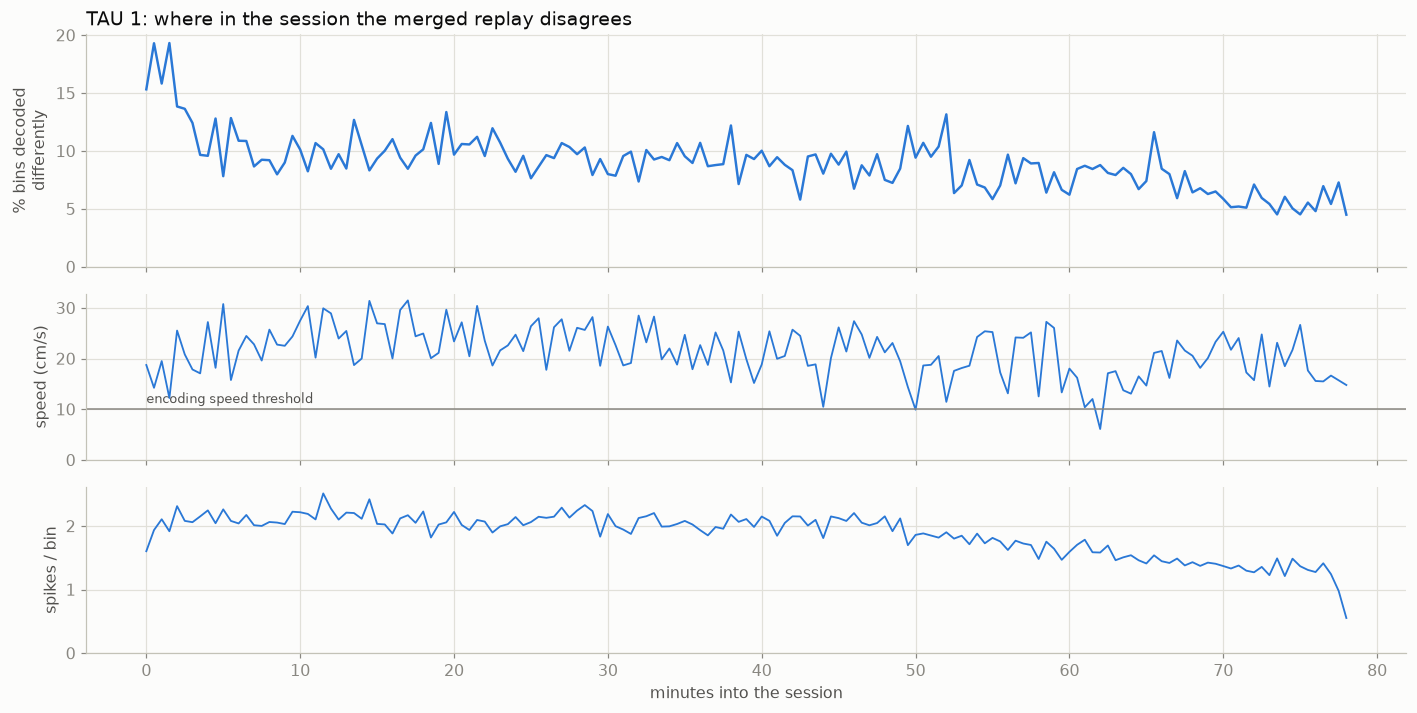

disagreement while moving : 7.39%  (48% of bins)
disagreement while still  : 10.53%


In [10]:
win = np.floor(bins.minutes * 2) / 2                     # 30 s windows
g = bins.assign(win=win).groupby('win')
rate = g[f'diff_{k}'].mean() * 100
speed = g['speed'].mean()
spk = g['n_spikes'].mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 6.6), sharex=True,
                         gridspec_kw={'height_ratios': [1.4, 1, 1]})
axes[0].plot(rate.index, rate.values, color=PAL[0], lw=1.6)
axes[0].set_ylabel('% bins decoded\ndifferently')
axes[0].set_title(f'TAU {k}: where in the session the merged replay disagrees', loc='left')
axes[1].plot(speed.index, speed.values, color=PAL[0], lw=1.2)
axes[1].axhline(run.cfg['encoder']['vel_thresh'], color=MUTED, lw=1)
axes[1].annotate('encoding speed threshold', (speed.index[0], run.cfg['encoder']['vel_thresh']),
                 xytext=(0, 4), textcoords='offset points', fontsize=8.5, color=INK2)
axes[1].set_ylabel('speed (cm/s)')
axes[2].plot(spk.index, spk.values, color=PAL[0], lw=1.2)
axes[2].set_ylabel('spikes / bin')
axes[2].set_xlabel('minutes into the session')
for ax in axes:
    ax.set_ylim(0, None); style_ax(ax)
fig.tight_layout(); plt.show()

moving = bins.speed >= run.cfg['encoder']['vel_thresh']
print(f'disagreement while moving : {pct(diff[moving.to_numpy()]):.2f}%  ({moving.mean()*100:.0f}% of bins)')
print(f'disagreement while still  : {pct(diff[~moving.to_numpy()]):.2f}%')

### 4b. On the maze

Left: grouped by the hex the **unmerged** replay decoded. Right: grouped by where the animal
**actually** was. Grey hexes have fewer than `MIN_BINS` bins.

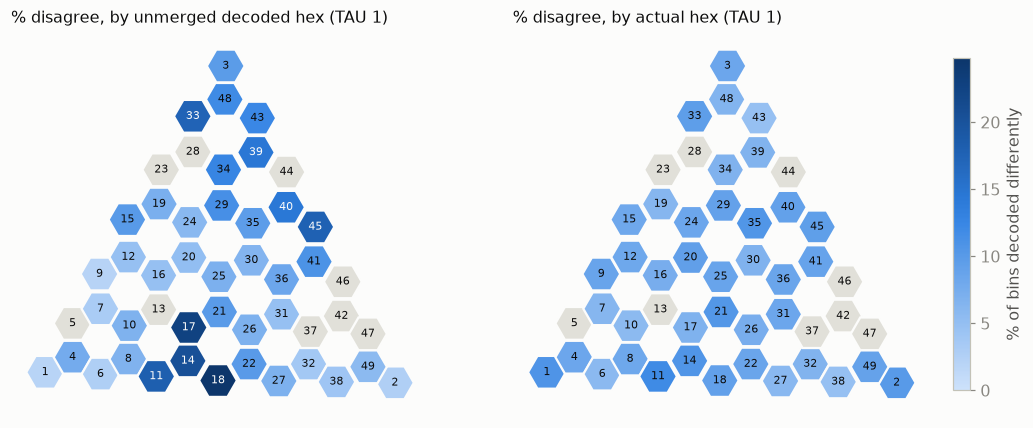

In [11]:
MIN_BINS = 500     # 3 s of bins; hexes with fewer are drawn grey

pos_cfg = run.cfg['encoder']['position']
cen = pd.read_csv(pos_cfg['hex_centroid_file']).set_index('hex').reindex(run.hex_ids)
XY = cen[['x', 'y']].to_numpy(float)
Dm = np.hypot(*(XY[:, None, :] - XY[None, :, :]).T); np.fill_diagonal(Dm, np.inf)
NN = float(np.median(Dm.min(axis=1)))
nbr = np.argmin(Dm, axis=1)
ang = np.degrees(np.arctan2(XY[nbr, 1] - XY[:, 1], XY[nbr, 0] - XY[:, 0])) % 60
ORIENT = 0.0 if np.mean(np.minimum(ang, 60 - ang) < 15) > 0.5 else np.pi / 6
RADIUS = NN / np.sqrt(3) * 0.96

def draw_hex_map(ax, values, n, *, vmax, title):
    norm = mpl.colors.Normalize(0, vmax)
    for i, (h, (x, y)) in enumerate(zip(run.hex_ids, XY)):
        val, cnt = values.get(i, np.nan), n.get(i, 0)
        shown = np.isfinite(val) and cnt >= MIN_BINS
        face = CM_BLUE(norm(val)) if shown else GRID
        ax.add_patch(RegularPolygon((x, y), 6, radius=RADIUS, orientation=ORIENT,
                                    facecolor=face, edgecolor=SURF, linewidth=1.5))
        txt = INK if (not shown or norm(val) < 0.55) else SURF
        ax.text(x, y, str(h), ha='center', va='center', fontsize=7, color=txt)
    ax.set_xlim(XY[:, 0].min() - NN, XY[:, 0].max() + NN)
    ax.set_ylim(XY[:, 1].max() + NN, XY[:, 1].min() - NN)   # image coords: y grows downward
    ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
    ax.set_title(title, fontsize=10.5, loc='left')
    return mpl.cm.ScalarMappable(norm=norm, cmap=CM_BLUE)

by_dec = bins.groupby('dec_unmerged')[f'diff_{k}']
valid = bins.actual_idx >= 0
by_act = bins[valid].groupby('actual_idx')[f'diff_{k}']
v_dec, n_dec = by_dec.mean() * 100, by_dec.size()
v_act, n_act = by_act.mean() * 100, by_act.size()
vmax = np.nanmax(np.r_[v_dec[n_dec >= MIN_BINS].values, v_act[n_act >= MIN_BINS].values, 1e-9])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
sm = draw_hex_map(axes[0], v_dec, n_dec, vmax=vmax, title=f'% disagree, by unmerged decoded hex (TAU {k})')
draw_hex_map(axes[1], v_act, n_act, vmax=vmax, title=f'% disagree, by actual hex (TAU {k})')
fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02, label='% of bins decoded differently')
plt.show()

### 4c. When the decoder is unsure

If merging only flips bins where the unmerged decoder was already split between hexes, the
disagreement should be concentrated at low posterior peaks.

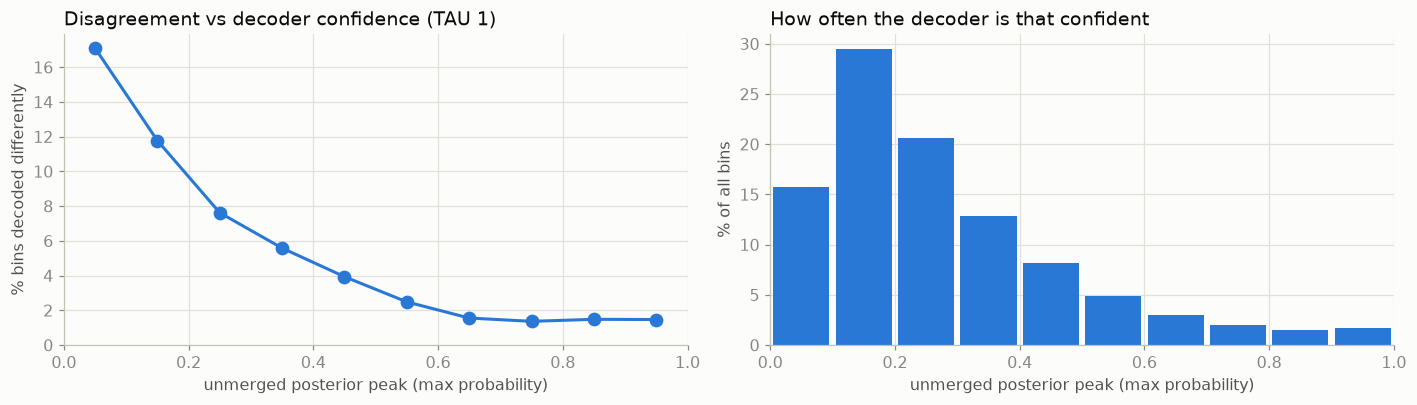

gap between the top two hexes (unmerged), median: disagreeing bins 0.0081, agreeing bins 0.0459


In [12]:
edges = np.linspace(0, 1, 11)
cb = np.clip(np.digitize(bins.pmax_unmerged, edges) - 1, 0, 9)
grp = pd.Series(diff).groupby(cb)
mid = (edges[:-1] + edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(mid[grp.mean().index], grp.mean().values * 100, color=PAL[0], marker='o', ms=8)
axes[0].set_xlabel('unmerged posterior peak (max probability)')
axes[0].set_ylabel('% bins decoded differently')
axes[0].set_title(f'Disagreement vs decoder confidence (TAU {k})', loc='left')
axes[0].set_ylim(0, None)
axes[1].bar(mid[grp.size().index], grp.size().values / len(diff) * 100, width=0.09, color=PAL[0])
axes[1].set_xlabel('unmerged posterior peak (max probability)')
axes[1].set_ylabel('% of all bins')
axes[1].set_title('How often the decoder is that confident', loc='left')
for ax in axes:
    ax.set_xlim(0, 1); style_ax(ax)
fig.tight_layout(); plt.show()

srt = np.sort(post0, axis=1)
margin = srt[:, -1] - srt[:, -2]          # top hex minus runner-up, unmerged
print(f'gap between the top two hexes (unmerged), median: disagreeing bins {np.median(margin[diff]):.4f}, '
      f'agreeing bins {np.median(margin[~diff]):.4f}')

### 4d. How far apart are the two decoded hexes?

1 step = neighbouring hexes. Distances are hops on the session's open maze.

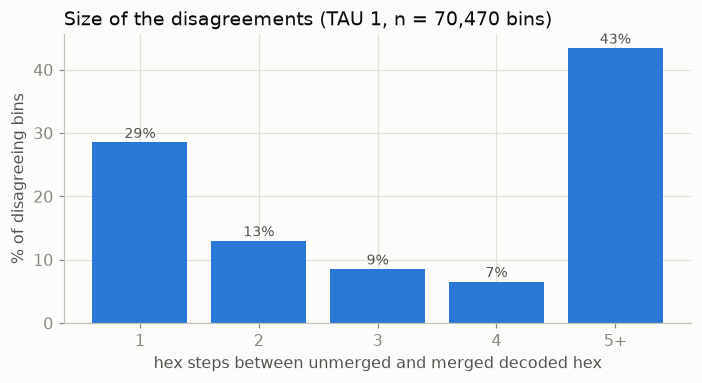

45,972 disagreement episodes; median 1 bin (6 ms), 90th percentile 2 bins, longest 90 bins (540 ms)


In [13]:
h = bins.loc[diff, f'hops_{k}'].to_numpy()
labels = ['1', '2', '3', '4', '5+']
counts = [np.sum(h == 1), np.sum(h == 2), np.sum(h == 3), np.sum(h == 4), np.sum(h >= 5)]
share = np.array(counts) / max(len(h), 1) * 100

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(labels, share, color=PAL[0], width=0.8)
for i, s in enumerate(share):
    ax.annotate(f'{s:.0f}%', (i, s), xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9, color=INK2)
ax.set_xlabel('hex steps between unmerged and merged decoded hex')
ax.set_ylabel('% of disagreeing bins')
ax.set_title(f'Size of the disagreements (TAU {k}, n = {len(h):,} bins)', loc='left')
style_ax(ax); fig.tight_layout(); plt.show()

# how long does a disagreement last? (consecutive differing bins)
e = np.diff(np.r_[0, diff.astype(int), 0])
lengths = np.flatnonzero(e == -1) - np.flatnonzero(e == 1)
tb_ms = run.cfg['decoder']['time_bin']['samples'] / FS * 1e3
print(f'{len(lengths):,} disagreement episodes; median {np.median(lengths):.0f} bin '
      f'({np.median(lengths)*tb_ms:.0f} ms), 90th percentile {np.percentile(lengths, 90):.0f} bins, '
      f'longest {lengths.max()} bins ({lengths.max()*tb_ms:.0f} ms)')

### 4e. The worst stretches, up close

For each of *moving* (≥ 80% of the window's bins above the encoding speed threshold) and *still*
(≤ 20%): the `N_PER_GROUP` non-overlapping `WINDOW_S`-second windows with the most disagreeing
bins. Top: unmerged posterior; middle: merged posterior (same colour scale); the orange line is
the animal's actual hex. Bottom strip: bins where the decoded hex differs.

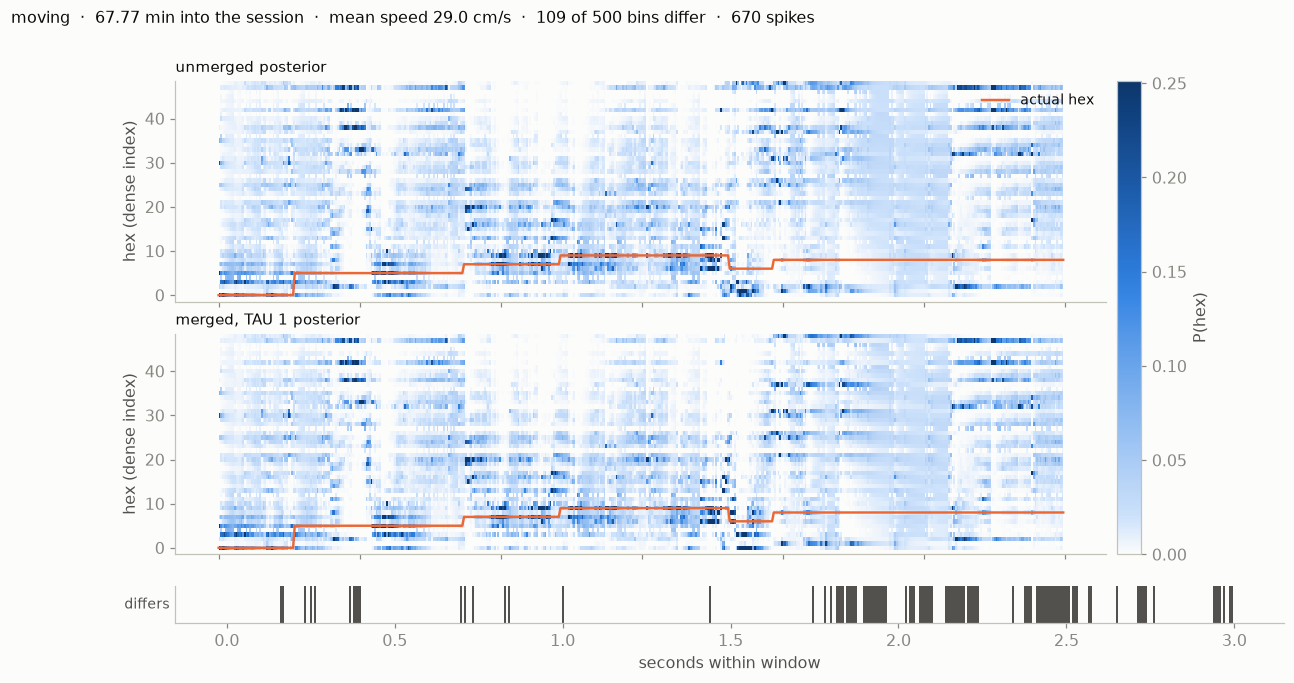

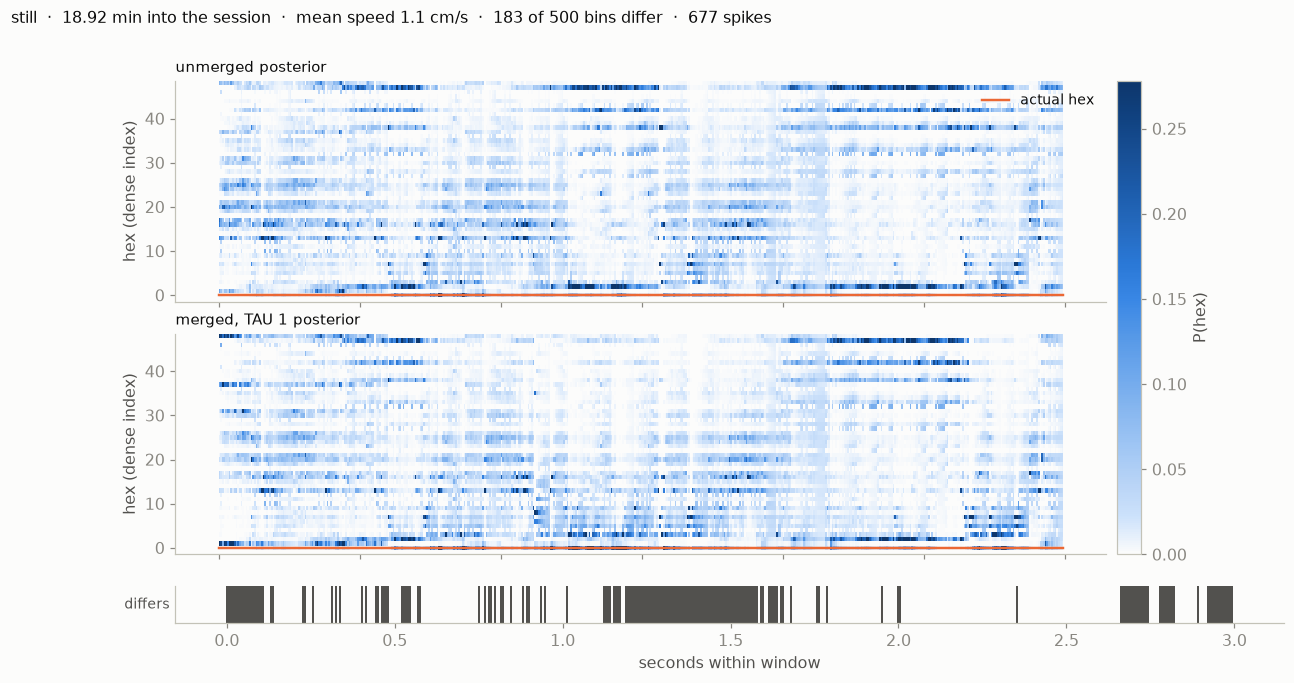

In [14]:
N_PER_GROUP = 1
WINDOW_S    = 3.0
W = int(round(WINDOW_S * FS / run.cfg['decoder']['time_bin']['samples']))

score = np.convolve(diff.astype(float), np.ones(W), mode='valid')
win_speed = np.convolve(bins.speed.to_numpy(), np.ones(W) / W, mode='valid')
frac_moving = np.convolve((bins.speed >= run.cfg['encoder']['vel_thresh']).to_numpy(float),
                          np.ones(W) / W, mode='valid')
picked, taken = [], np.zeros(len(diff), bool)
for group, ok in (('moving', frac_moving >= 0.8), ('still', frac_moving <= 0.2)):
    n = 0
    for s in np.argsort(-np.where(ok, score, -1)):
        if n == N_PER_GROUP or not ok[s] or score[s] == 0:
            break
        if not taken[s:s + W].any():
            picked.append((group, s)); n += 1
            taken[max(0, s - W):s + 2 * W] = True

post_m = R[TAU_VIEW]['posterior']
for group, s in picked:
    sl = slice(s, s + W)
    t = (bins.minutes.to_numpy()[sl] - bins.minutes.iloc[s]) * 60
    vmax = np.percentile(np.r_[post0[sl].ravel(), post_m[sl].ravel()], 99.5)
    act = bins.actual_idx.to_numpy()[sl].astype(float); act[act < 0] = np.nan
    fig, axes = plt.subplots(3, 1, figsize=(13, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [3, 3, 0.5]})
    for ax, P, name in ((axes[0], post0, 'unmerged'), (axes[1], post_m, f'merged, TAU {k}')):
        im = ax.imshow(P[sl].T, aspect='auto', origin='lower', cmap=CM_POST, vmin=0, vmax=vmax,
                       extent=[t[0], t[-1], -0.5, run.num_bins - 0.5], interpolation='nearest')
        ax.plot(t, act, color=C_MERGED, lw=1.6, label='actual hex')
        ax.set_ylim(-1.5, run.num_bins - 0.5)     # keeps an actual hex of index 0 visible
        ax.set_ylabel('hex (dense index)'); ax.grid(False)
        ax.set_title(f'{name} posterior', loc='left', fontsize=10)
    axes[0].legend(loc='upper right', fontsize=9)
    axes[2].bar(t, diff[sl].astype(float), width=t[1] - t[0], color=INK2)
    axes[2].set_yticks([]); axes[2].set_ylim(0, 1); axes[2].grid(False)
    axes[2].set_ylabel('differs', rotation=0, ha='right', va='center', fontsize=9)
    axes[2].set_xlabel('seconds within window')
    fig.suptitle(f'{group}  ·  {bins.minutes.iloc[s]:.2f} min into the session  ·  '
                 f'mean speed {win_speed[s]:.1f} cm/s  ·  '
                 f'{int(diff[sl].sum())} of {W} bins differ  ·  '
                 f'{int(bins.n_spikes.to_numpy()[sl].sum())} spikes', x=0.01, ha='left', fontsize=10.5)
    fig.colorbar(im, ax=axes[:2], pad=0.01, label='P(hex)')
    plt.show()

## 5. Caveats

- **Replay, not the live run.** Both replays decode every spike the encoders sent. The live run
  used fewer (late spikes are dropped), so its decoded hexes differ from the unmerged replay much
  more than merging does — see the "for scale" line in section 3. Merging is measured against
  the unmerged replay, never against the live output.
- **Positions are as the encoder stored them.** In runs recorded before 2026-10-07, an encoder that
  fell behind real time stored each spike with the animal's *current* hex rather than the hex at the
  spike's time (fixed in the encoder since; see `docs/kernel_compression_plan.md`, decision 8). Both
  replays inherit those positions, so the comparison is fair, but absolute decoding quality in such
  runs is affected by it.
- **Send rule with merging** counts bump weights (counts) whose centers fall inside the
  ±n_std·σ box, instead of counting stored marks.
- **Spikes sent only by the merged model** have no logged vote to borrow the encoder's occupancy
  from; their votes use the decoder's logged occupancy at the same wall-clock time, minus 1
  (the encoder starts at 0, the decoder at 1). Counts are printed in section 2.
- **Timings are offline**, single process on an idle machine, worst case (final model). The live
  encoder shares the machine with every other rank and runs slower; compare thresholds with each
  other and with the 6 ms bin, not with live latencies.
- **Weight-only merging**: merged bumps keep the default width σ — the version chosen for the
  encoder change.